# *SMART INDUSTRY ANOMALY DETECTION DATASET(SIADD) FOR CYBER-PHYSICAL THREAT MONITIORING IN INDUSTRIAL IOT ENVIRONMENTS.*

# *Import the Necessary Libraries*

In [1]:
#Importing Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

from collections import Counter
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support, confusion_matrix
import joblib
import os

C:\Users\1158\AppData\Local\Temp\ipykernel_19964\688941840.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


# *Read the Data Set*

In [2]:
# Column names for the dataset
column_names = [ 
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login", "is_guest_login", "count", "srv_count",
    "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "attack", "difficulty"
]

# Load training and test sets (replace with actual paths)
df = pd.read_csv("data//KDDTrain+.txt", names=column_names)

# Drop the 'difficulty' column (not needed)
df.drop('difficulty', axis=1, inplace=True)

print(df.shape)

(125973, 42)


In [3]:
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


# **Exploratory Data Analysis (EDA)**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

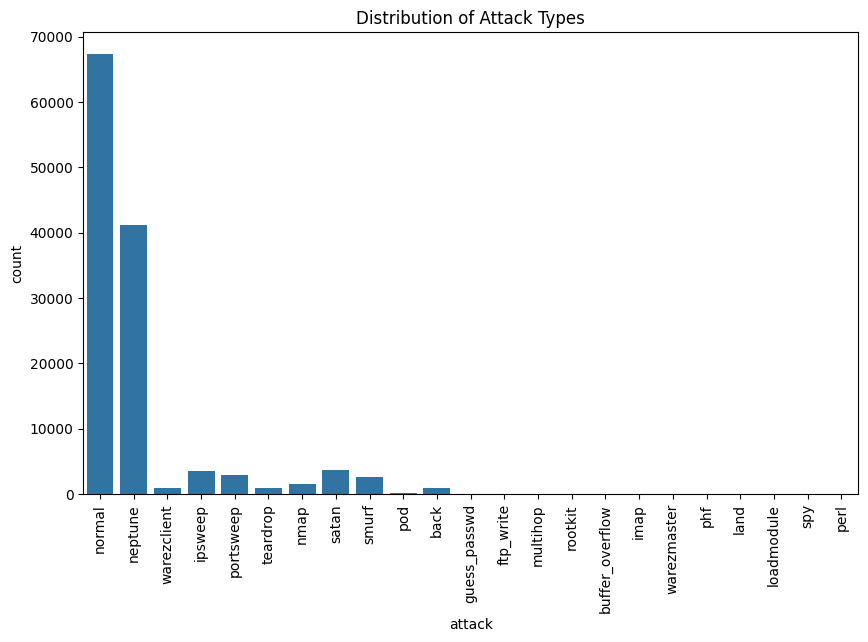

In [5]:
# Plotting the value counts
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='attack')
plt.title('Distribution of Attack Types')
plt.xticks(rotation=90)
plt.show()

In [6]:
# Define the attack mapping
attack_mapping = {
    'normal': 'normal',
    'neptune': 'Dos', 'smurf': 'Dos', 'pod': 'Dos', 'teardrop': 'Dos', 'back': 'Dos', 'land': 'Dos',
    'satan': 'Probing', 'ipsweep': 'Probing', 'portsweep': 'Probing', 'nmap': 'Probing',
    'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L', 'phf': 'R2L', 'multihop': 'R2L',
    'warezclient': 'R2L', 'warezmaster': 'R2L', 'spy': 'R2L', 'perl': 'R2L',
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'rootkit': 'U2R'
}

# Map 'attack' column to the new 'attack_category' using the attack_mapping dictionary
df['attack_category'] = df['attack'].map(attack_mapping)

# Check the distribution of the 'attack_category' column
print(df['attack_category'].value_counts())

attack_category
normal     67343
Dos        45927
Probing    11656
R2L          998
U2R           49
Name: count, dtype: int64


In [7]:
# Check the distribution of the 'attack_category' column
print(df['attack_category'].value_counts())

attack_category
normal     67343
Dos        45927
Probing    11656
R2L          998
U2R           49
Name: count, dtype: int64


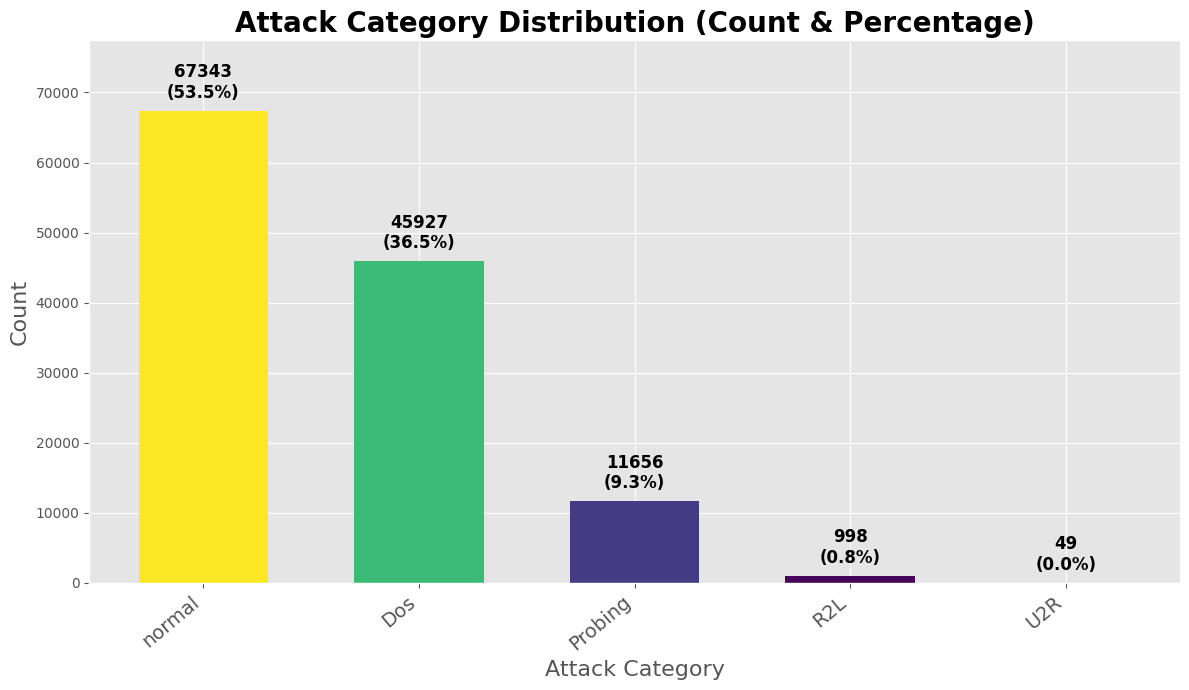

In [8]:
# Apply the 'ggplot' style for a clean and modern look
plt.style.use('ggplot')

# Set the figure size
plt.figure(figsize=(12, 7))

# Get counts for each attack category
attack_counts = df['attack_category'].value_counts().sort_values(ascending=False)

# Normalize the count values for color mapping
norm = plt.Normalize(attack_counts.min(), attack_counts.max())
colors = plt.cm.viridis(norm(attack_counts.values))

# Create a bar plot for attack category distribution
bars = plt.bar(attack_counts.index, attack_counts.values, color=colors, width=0.6)

# Total count for percentage calculation
total = attack_counts.sum()

# Add count and percentage annotations on top of each bar
for bar, count in zip(bars, attack_counts.values):
    height = bar.get_height()
    percentage = (count / total) * 100
    # Adding text for both count and percentage
    plt.text(bar.get_x() + bar.get_width() / 2, height + total * 0.01,
             f'{count}\n({percentage:.1f}%)', ha='center', va='bottom',
             fontsize=12, fontweight='bold', color='black')

# Title and labels with larger font sizes for better readability
plt.title('Attack Category Distribution (Count & Percentage)', fontsize=20, fontweight='bold')
plt.xlabel('Attack Category', fontsize=16)
plt.ylabel('Count', fontsize=16)

# Rotate x-ticks for better visibility, especially for long category names
plt.xticks(rotation=40, ha='right', fontsize=14)

# Set the y-axis limit to provide enough space for annotations
plt.ylim(0, attack_counts.max() * 1.15)

# Add a tight layout to prevent clipping of the labels
plt.tight_layout()

# Display the plot
plt.show()

# The dataset shows a high class imbalance, with normal traffic making up over half (53.5%) of the data, while DoS attacks are the second largest category at 36.5%. The remaining attack categories (probing, R2L, U2R) are much less frequent.

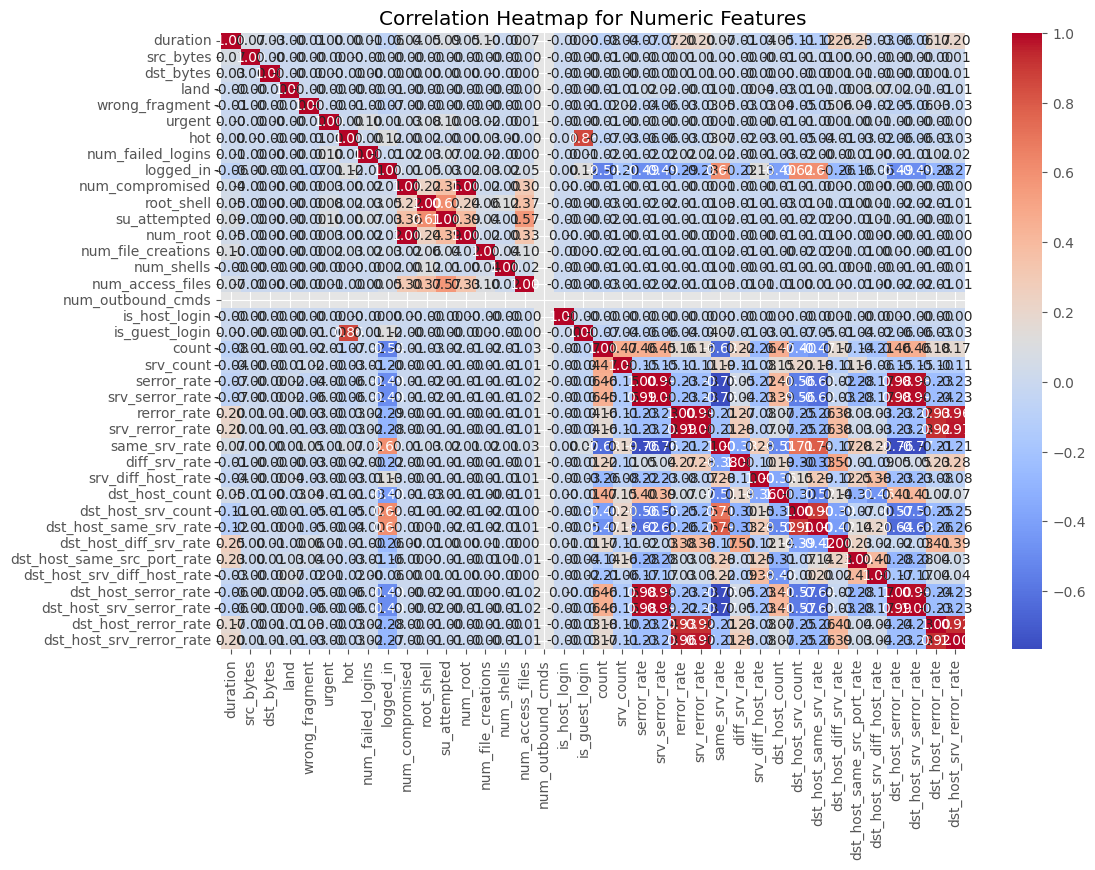

In [9]:
numeric_columns = df.select_dtypes(include=['number']).columns

# Calculate the correlation matrix for the numeric features
correlation_matrix = df[numeric_columns].corr()

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap for Numeric Features")
plt.show()

# *The heatmap shows strong correlations between features like num_failed_logins and num_file_creations (0.99), indicating redundancy. Features like srv_serror_rate and srv_rerror_rate are also highly correlated, suggesting potential removal to reduce multicollinearity. We will remove highly correlated features to simplify the model and improve generalization.*

In [10]:
#  Compute the correlation matrix for training data
train_corr_matrix = df[numeric_columns].corr()

# Create an upper triangle matrix to avoid redundant comparisons
upper = train_corr_matrix.where(np.triu(np.ones(train_corr_matrix.shape), k=1).astype(bool))

# Identify features with correlation greater than a threshold (e.g., 0.8)
threshold = 0.8
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

#  Remove highly correlated features from the training data
df_reduced = df.drop(columns=to_drop)


# Print the removed columns and the new shapes
print(f"Removed columns: {to_drop}")
print(f"Reduced training data shape: {df_reduced.shape}")


Removed columns: ['num_root', 'is_guest_login', 'srv_serror_rate', 'srv_rerror_rate', 'dst_host_same_srv_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']
Reduced training data shape: (125973, 34)


In [11]:
df_reduced.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,attack,attack_category
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,1.00,0.00,0.00,150,25,0.03,0.17,0.00,normal,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,0.08,0.15,0.00,255,1,0.60,0.88,0.00,normal,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.07,0.00,255,26,0.05,0.00,0.00,neptune,Dos
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.00,30,255,0.00,0.03,0.04,normal,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.09,255,255,0.00,0.00,0.00,normal,normal


In [12]:
df_reduced['attack_category'].value_counts()

attack_category
normal     67343
Dos        45927
Probing    11656
R2L          998
U2R           49
Name: count, dtype: int64

In [13]:
# Filter the rows where 'attack_category' is 'probing'
df_probing = df_reduced[df_reduced['attack_category'] == 'R2L']

# Display the filtered DataFrame
df_probing.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,attack,attack_category
13,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,1.0,0.0,0.0,2,20,0.00,1.0,0.20,warezclient,R2L
48,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,1.0,0.0,0.0,4,38,0.00,1.0,0.18,warezclient,R2L
148,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,1.0,0.0,0.0,6,26,0.00,1.0,0.19,warezclient,R2L
190,15159,tcp,ftp,SF,350,1185,0,0,0,6,...,1.0,0.0,1.0,255,142,0.02,0.0,0.00,warezclient,R2L
222,4,tcp,ftp_data,SF,832,0,0,0,0,0,...,1.0,0.0,0.0,3,28,0.00,1.0,0.18,warezclient,R2L


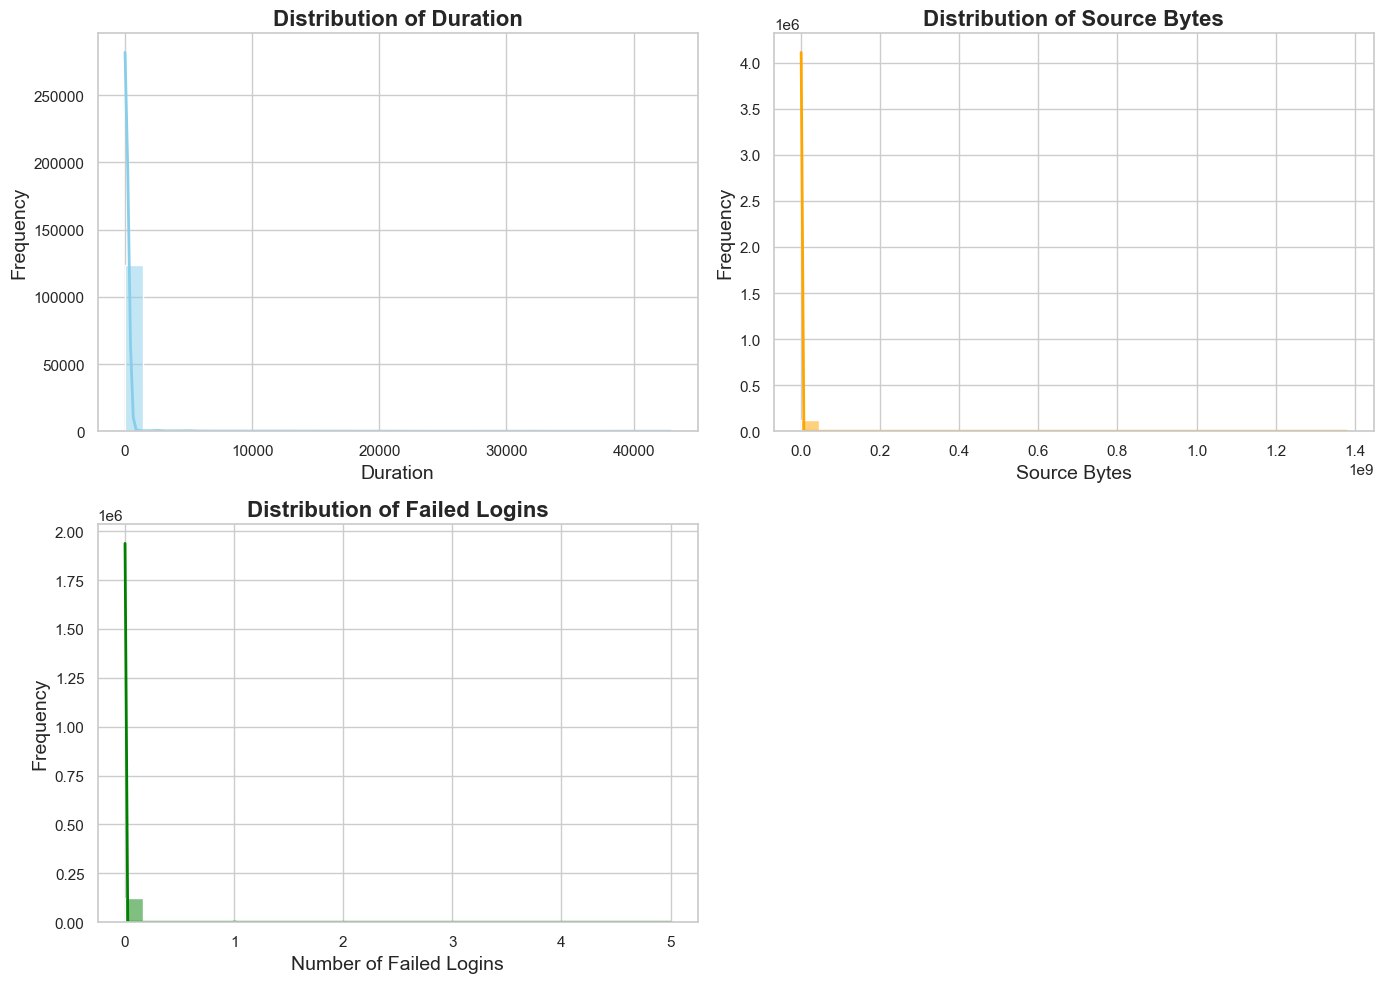

In [14]:
sns.set(style="whitegrid")

# Create a figure with a larger size
plt.figure(figsize=(14, 10))

# Duration Histogram with KDE
plt.subplot(2, 2, 1)
sns.histplot(df_reduced['duration'], kde=True, color='skyblue', bins=30, line_kws={'color': 'darkblue', 'linewidth': 2})
plt.title('Distribution of Duration', fontsize=16, fontweight='bold')
plt.xlabel('Duration', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# src_bytes Histogram with KDE
plt.subplot(2, 2, 2)
sns.histplot(df_reduced['src_bytes'], kde=True, color='orange', bins=30, line_kws={'color': 'darkorange', 'linewidth': 2})
plt.title('Distribution of Source Bytes', fontsize=16, fontweight='bold')
plt.xlabel('Source Bytes', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# num_failed_logins Histogram with KDE
plt.subplot(2, 2, 3)
sns.histplot(df_reduced['num_failed_logins'], kde=True, color='green', bins=30, line_kws={'color': 'darkgreen', 'linewidth': 2})
plt.title('Distribution of Failed Logins', fontsize=16, fontweight='bold')
plt.xlabel('Number of Failed Logins', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# Adjust layout for better spacing and visual clarity
plt.tight_layout()

# Show the plot
plt.show()

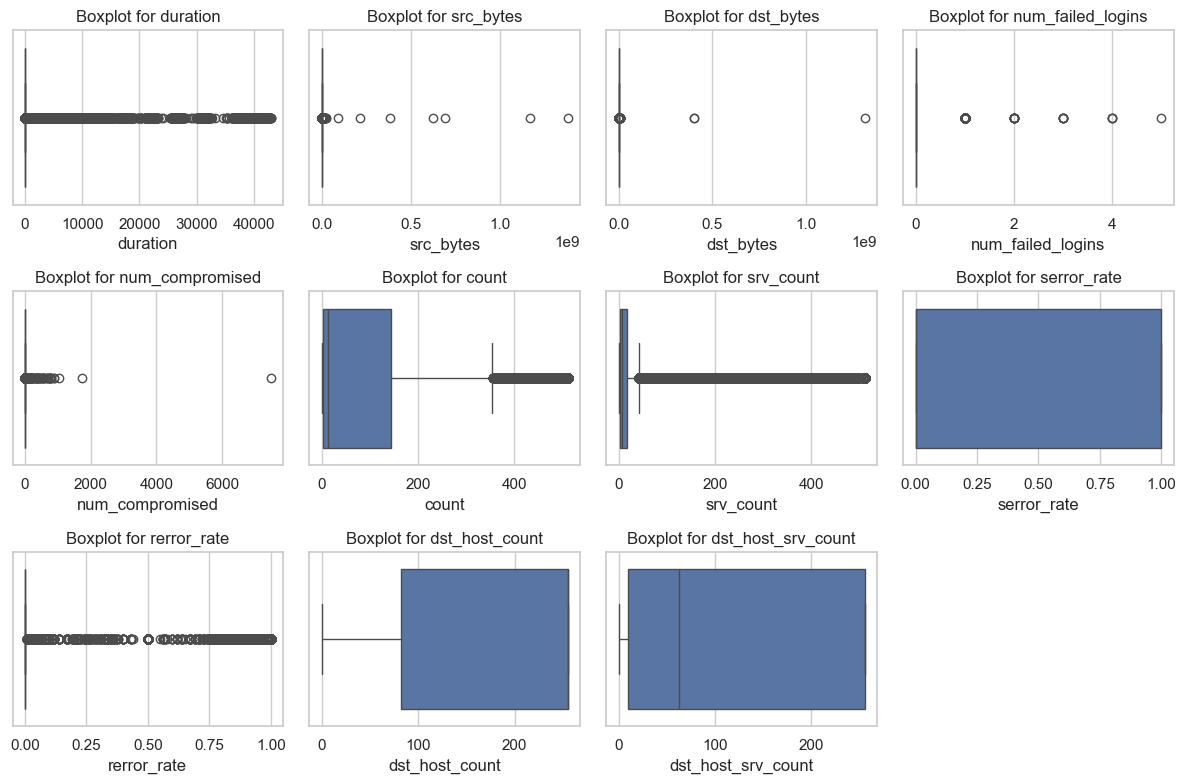

In [15]:
# Columns you are interested in checking for outliers
important_columns = [
 "duration", "src_bytes", "dst_bytes", "num_failed_logins", "num_compromised", 
    "count", "srv_count", "serror_rate", "rerror_rate", "dst_host_count", "dst_host_srv_count"
]   

# Calculate the number of rows and columns for subplots
num_columns = 4  # Set the number of columns for your plots
num_rows = (len(important_columns) + num_columns - 1) // num_columns  # Calculate rows dynamically

# Plot boxplots for each important column
plt.figure(figsize=(12, 8))
for i, column in enumerate(important_columns, 1):
    plt.subplot(num_rows, num_columns, i)  # Set up subplots dynamically
    sns.boxplot(x=df_reduced[column])
    plt.title(f'Boxplot for {column}')

plt.tight_layout()
plt.show()

# The boxplots show several features with significant outliers, especially in duration, src_bytes, and num_compromised. These outliers may skew the analysis and impact model performance. We plan to cap these outliers to ensure more stable and accurate model training.

In [16]:
def cap_outliers(df, feature, lower_bound, upper_bound):
    # Cap values that are below the lower bound to the lower bound, 
    # and values above the upper bound to the upper bound
    df[feature] = df[feature].clip(lower=lower_bound, upper=upper_bound)
    return df

# Calculate the IQR bounds on the training data first
lower_bounds = {}
upper_bounds = {}
for column in important_columns:
    Q1 = df_reduced[column].quantile(0.25)
    Q3 = df_reduced[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bounds[column] = Q1 - 1.5 * IQR
    upper_bounds[column] = Q3 + 1.5 * IQR

# Apply capping to both training and test data
for column in important_columns:
    # Apply capping on training data
    df_reduced = cap_outliers(df_reduced, column, lower_bounds[column], upper_bounds[column])
    

In [17]:
df_reduced.shape


(125973, 34)

In [18]:
df_reduced.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
count                          0
srv_count                      0
serror_rate                    0
rerror_rate                    0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_host_rate             0
dst_host_count                 0
dst_host_srv_count             0
dst_host_diff_srv_rate         0
dst_host_s

In [19]:
df_reduced['attack_category'].value_counts()

attack_category
normal     67343
Dos        45927
Probing    11656
R2L          998
U2R           49
Name: count, dtype: int64

In [20]:
df_reduced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 34 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [21]:
# Encode categorical features
categorical_columns = ['protocol_type', 'service', 'flag']
feature_encoder = LabelEncoder()

for column in categorical_columns:
    df_reduced[column] = feature_encoder.fit_transform(df_reduced[column])

# Encode the target variable
target_encoder = LabelEncoder()
df_reduced['attack_category'] = target_encoder.fit_transform(df_reduced['attack_category'])

In [22]:
df_reduced['attack_category'].value_counts()

attack_category
4    67343
0    45927
1    11656
2      998
3       49
Name: count, dtype: int64

In [23]:
df_reduced.drop(columns='attack', inplace=True)

In [24]:
df_reduced

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,attack_category
0,0,1,20,9,491,0,0,0,0,0,...,0.0,1.00,0.00,0.00,150,25,0.03,0.17,0.00,4
1,0,2,44,9,146,0,0,0,0,0,...,0.0,0.08,0.15,0.00,255,1,0.60,0.88,0.00,4
2,0,1,49,5,0,0,0,0,0,0,...,0.0,0.05,0.07,0.00,255,26,0.05,0.00,0.00,0
3,0,1,24,9,232,1290,0,0,0,0,...,0.0,1.00,0.00,0.00,30,255,0.00,0.03,0.04,4
4,0,1,24,9,199,420,0,0,0,0,...,0.0,1.00,0.00,0.09,255,255,0.00,0.00,0.00,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,1,49,5,0,0,0,0,0,0,...,0.0,0.14,0.06,0.00,255,25,0.06,0.00,0.00,0
125969,0,2,49,9,105,145,0,0,0,0,...,0.0,1.00,0.00,0.00,255,244,0.01,0.01,0.00,4
125970,0,1,54,9,690,384,0,0,0,0,...,0.0,1.00,0.00,0.00,255,30,0.06,0.00,0.00,4
125971,0,1,30,5,0,0,0,0,0,0,...,0.0,0.06,0.05,0.00,255,8,0.05,0.00,0.00,0


In [25]:
# Check if we have all attack categories
print("Unique attack categories:", df_reduced['attack_category'].unique())
print("Encoded values:", df_reduced['attack_category'].unique())
print("Class distribution after encoding:")
print(df_reduced['attack_category'].value_counts())

Unique attack categories: [4 0 2 1 3]
Encoded values: [4 0 2 1 3]
Class distribution after encoding:
attack_category
4    67343
0    45927
1    11656
2      998
3       49
Name: count, dtype: int64


In [26]:
df_reduced.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  int32  
 2   service                      125973 non-null  int32  
 3   flag                         125973 non-null  int32  
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [27]:
# Print the label encoding mapping to see the correspondence between the original label and the encoded value
label_mapping = dict(zip(target_encoder.classes_, range(len(target_encoder.classes_))))
print(f"Label encoding mapping: {label_mapping}")

# Get the encoded value for 'R2L'
encoded_r2l = label_mapping.get('normal')
if encoded_r2l is not None:
    print(f"Encoded value for 'R2L': {encoded_r2l}")

    # Filter the rows where 'attack_category' is the encoded value for 'R2L'
    r2l_rows = df_reduced[df_reduced['attack_category'] == encoded_r2l]

    # Define the list of columns you're interested in
    columns_of_interest = [
        'src_bytes', 'dst_host_srv_count', 'dst_bytes', 'dst_host_diff_srv_rate',
        'service', 'serror_rate', 'dst_host_same_src_port_rate', 'logged_in',
        'count', 'diff_srv_rate'
    ]

    # Select the first 3 rows from the filtered data and the specified columns
    first_3_r2l_rows = r2l_rows[columns_of_interest].head(3)

    # Display the result
    print(first_3_r2l_rows)
else:
    print("No 'R2L' category found in the encoding mapping.")

Label encoding mapping: {'Dos': 0, 'Probing': 1, 'R2L': 2, 'U2R': 3, 'normal': 4}
Encoded value for 'R2L': 4
   src_bytes  dst_host_srv_count  dst_bytes  dst_host_diff_srv_rate  service  \
0        491                  25          0                    0.03       20   
1        146                   1          0                    0.60       44   
3        232                 255       1290                    0.00       24   

   serror_rate  dst_host_same_src_port_rate  logged_in  count  diff_srv_rate  
0          0.0                         0.17          0    2.0           0.00  
1          0.0                         0.88          0   13.0           0.15  
3          0.2                         0.03          1    5.0           0.00  


In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
# from imblearn.over_sampling import SMOTE, RandomOverSampler
# from imblearn.under_sampling import RandomUnderSampler

# Load your data (assuming df_reduced is already defined)
X = df_reduced.drop(columns=['attack_category'])
y = df_reduced['attack_category']

print("Original class distribution:")
print(y.value_counts().sort_index())



Original class distribution:
attack_category
0    45927
1    11656
2      998
3       49
4    67343
Name: count, dtype: int64


In [29]:
# Separate the dataset by classes
class_0 = df_reduced[df_reduced['attack_category'] == 0]
class_1 = df_reduced[df_reduced['attack_category'] == 1]
class_2 = df_reduced[df_reduced['attack_category'] == 2]
class_3 = df_reduced[df_reduced['attack_category'] == 3]
class_4 = df_reduced[df_reduced['attack_category'] == 4]

# Keep only the first 11,000 rows of class 0, 1, and 4
class_0 = class_0.head(11000)
class_1 = class_1.head(11000)
class_4 = class_4.head(11000)

# For classes 2 and 3, use a custom oversampling technique to bring them to 5,000 samples
# Manually repeat the rows to achieve 5,000 samples
class_2 = class_2.sample(n=5000, replace=True, random_state=42)
class_3 = class_3.sample(n=5000, replace=True, random_state=42)

# Combine all classes
df_reduced_final = pd.concat([class_0, class_1, class_2, class_3, class_4])

# Shuffle the dataset to mix the rows
df_reduced_final = df_reduced_final.sample(frac=1, random_state=42).reset_index(drop=True)

# Separate features and target after reduction
X_reduced_final = df_reduced_final.drop(columns=['attack_category'])
y_reduced_final = df_reduced_final['attack_category']

# Class distribution after reduction
print("Reduced class distribution:")
print(y_reduced_final.value_counts().sort_index())

Reduced class distribution:
attack_category
0    11000
1    11000
2     5000
3     5000
4    11000
Name: count, dtype: int64


In [30]:
# Combine X_reduced_final (features) and y_reduced_final (target) into a single DataFrame
# We use the index from X_reduced_final to preserve the row index in the final DataFrame
df_combined = X_reduced_final.copy()  # Make a copy of the features DataFrame
df_combined['attack_category'] = y_reduced_final  # Add the target as a new column

# Print the first few rows of the combined DataFrame to verify
print(df_combined.head(5))


   duration  protocol_type  service  flag  src_bytes  dst_bytes  land  \
0         0              1       35     5          0          0     0   
1         0              1       49     5          0          0     0   
2         0              0       14     9          8          0     0   
3         0              1       24     1          0          0     0   
4         0              1       24     9        246       1290     0   

   wrong_fragment  urgent  hot  ...  rerror_rate  same_srv_rate  \
0               0       0    0  ...          0.0           0.02   
1               0       0    0  ...          0.0           0.09   
2               0       0    0  ...          0.0           1.00   
3               0       0    0  ...          0.0           1.00   
4               0       0    0  ...          0.0           1.00   

   diff_srv_rate  srv_diff_host_rate  dst_host_count  dst_host_srv_count  \
0           0.07                 0.0             255                   4   
1     

In [31]:
X_reduced_final.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,serror_rate,rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate
0,0,1,35,5,0,0,0,0,0,0,...,1.0,0.0,0.02,0.07,0.0,255,4,0.08,0.00,0.0
1,0,1,49,5,0,0,0,0,0,0,...,1.0,0.0,0.09,0.07,0.0,255,12,0.06,0.00,0.0
2,0,0,14,9,8,0,0,0,0,0,...,0.0,0.0,1.00,0.00,1.0,1,131,0.00,1.00,0.5
3,0,1,24,1,0,0,0,0,0,0,...,0.0,0.0,1.00,0.00,0.0,2,31,0.00,0.50,0.1
4,0,1,24,9,246,1290,0,0,0,0,...,0.0,0.0,1.00,0.00,0.0,17,17,0.00,0.06,0.0


In [32]:
# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_reduced_final, y_reduced_final, test_size=0.2, random_state=42)

In [34]:
from sklearn.ensemble import RandomForestClassifier
# Initialize and fit the RandomForest model

### Random Forest Feature Importance and Scaling with RobustScaler

In [35]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Get feature importances
feature_importances = rf_model.feature_importances_

# Create a DataFrame to display feature names with their importance scores
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Print the sorted features by importance
print("\nFeature importances:")
print(feature_importance_df)

# Select the top N important features (you can adjust this number)
top_n = 10  # You can change this to 10, 15, 20, etc.
top_n_features = feature_importance_df.head(top_n)['Feature'].tolist()
print(f"\nTop {top_n} selected features: {top_n_features}")

# Filter the training and test sets to only use the selected features
X_train_selected = X_train[top_n_features]
X_test_selected = X_test[top_n_features]

# Step 2: Apply RobustScaler to the selected features
print("\nApplying RobustScaler to selected features...")

# Initialize the RobustScaler
scaler = RobustScaler()

# Fit and transform the training data, and transform the test data
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

# Convert the scaled NumPy arrays back to DataFrames with feature names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=top_n_features)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=top_n_features)

print("Scaling completed successfully!")
print(f"X_train_scaled shape: {X_train_scaled_df.shape}")
print(f"X_test_scaled shape: {X_test_scaled_df.shape}")


Feature importances:
                        Feature  Importance
4                     src_bytes    0.120645
28           dst_host_srv_count    0.095597
5                     dst_bytes    0.088203
29       dst_host_diff_srv_rate    0.078279
2                       service    0.067031
22                  serror_rate    0.064472
30  dst_host_same_src_port_rate    0.063779
11                    logged_in    0.054982
20                        count    0.050383
25                diff_srv_rate    0.042370
27               dst_host_count    0.040940
21                    srv_count    0.038614
3                          flag    0.033500
9                           hot    0.033385
24                same_srv_rate    0.030632
31  dst_host_srv_diff_host_rate    0.027146
1                 protocol_type    0.025983
26           srv_diff_host_rate    0.013552
13                   root_shell    0.013130
15           num_file_creations    0.011767
7                wrong_fragment    0.003492
16        

In [44]:
# Combine the selected features and target for both train and test sets
train_data = X_train_scaled_df.copy()
train_data['Target'] = y_train

test_data = X_test_scaled_df.copy()
test_data['Target'] = y_test

# Save the data to CSV files
train_data.to_csv('train_data_with_selected_features.csv', index=False)
test_data.to_csv('test_data_with_selected_features.csv', index=False)

print("Data has been saved to 'train_data_with_selected_features.csv' and 'test_data_with_selected_features.csv'.")


Data has been saved to 'train_data_with_selected_features.csv' and 'test_data_with_selected_features.csv'.


In [43]:
X_train_scaled_df

,src_bytes,dst_host_srv_count,dst_bytes,dst_host_diff_srv_rate,service,serror_rate,dst_host_same_src_port_rate,logged_in,count,diff_srv_rate
0,0.000000,1.070175,0.000000,-0.285714,-0.344828,0.0,0.98,0.0,-0.017094,0.000000
1,2.221498,-0.087719,1.848138,-0.285714,1.241379,0.0,0.09,1.0,-0.017094,0.000000
2,-0.026059,-0.157895,0.000000,8.428571,0.862069,0.8,-0.02,0.0,1.290598,16.500000
3,-0.026059,-0.114035,0.000000,0.714286,1.517241,20.0,-0.02,0.0,1.905983,1.000000
4,0.117264,2.070175,0.063037,-0.285714,-0.413793,0.0,-0.01,0.0,0.829060,0.000000
...,...,...,...,...,...,...,...,...,...,...
34395,-0.026059,-0.043860,0.000000,0.857143,0.862069,20.0,-0.02,0.0,1.034188,1.000000
34396,2.221498,0.456140,1.848138,0.000000,-0.172414,0.0,-0.02,1.0,-0.017094,0.000000
34397,0.690554,2.070175,1.848138,-0.285714,0.000000,0.0,-0.02,1.0,-0.017094,0.000000
34398,-0.026059,-0.008772,0.000000,0.571429,1.034483,20.0,-0.02,0.0,0.547009,1.166667


In [37]:
X_train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,serror_rate,rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate
33137,0,0,14,9,8,0,0,0,0,0,...,0.00,0.0,1.00,0.00,1.00,1,141,0.00,1.00,0.5
16545,0,1,60,9,690,1290,0,0,0,3,...,0.00,0.0,1.00,0.00,0.00,9,9,0.00,0.11,0.0
28765,0,1,49,1,0,0,0,0,0,0,...,0.04,0.0,0.01,0.99,0.00,255,1,0.61,0.00,0.0
19031,0,1,68,5,0,0,0,0,0,0,...,1.00,0.0,0.03,0.06,0.00,255,6,0.07,0.00,0.0
23219,0,2,12,9,44,44,0,0,0,0,...,0.00,0.0,1.00,0.00,0.01,255,255,0.00,0.01,0.0


In [38]:
X_train_scaled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34400 entries, 0 to 34399
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   src_bytes                    34400 non-null  float64
 1   dst_host_srv_count           34400 non-null  float64
 2   dst_bytes                    34400 non-null  float64
 3   dst_host_diff_srv_rate       34400 non-null  float64
 4   service                      34400 non-null  float64
 5   serror_rate                  34400 non-null  float64
 6   dst_host_same_src_port_rate  34400 non-null  float64
 7   logged_in                    34400 non-null  float64
 8   count                        34400 non-null  float64
 9   diff_srv_rate                34400 non-null  float64
dtypes: float64(10)
memory usage: 2.6 MB


In [39]:
X_test_scaled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8600 entries, 0 to 8599
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   src_bytes                    8600 non-null   float64
 1   dst_host_srv_count           8600 non-null   float64
 2   dst_bytes                    8600 non-null   float64
 3   dst_host_diff_srv_rate       8600 non-null   float64
 4   service                      8600 non-null   float64
 5   serror_rate                  8600 non-null   float64
 6   dst_host_same_src_port_rate  8600 non-null   float64
 7   logged_in                    8600 non-null   float64
 8   count                        8600 non-null   float64
 9   diff_srv_rate                8600 non-null   float64
dtypes: float64(10)
memory usage: 672.0 KB


In [40]:
X_test_scaled_df.head()

,src_bytes,dst_host_srv_count,dst_bytes,dst_host_diff_srv_rate,service,serror_rate,dst_host_same_src_port_rate,logged_in,count,diff_srv_rate
0,0.029316,1.798246,0.060172,-0.142857,-0.413793,0.0,0.02,0.0,-0.017094,0.000000
1,-0.026059,-0.157895,0.000000,12.714286,0.862069,0.0,0.88,0.0,-0.008547,16.666667
2,-0.026059,-0.157895,0.000000,12.857143,0.862069,20.0,0.92,0.0,-0.017094,0.000000
3,0.000000,0.447368,0.000000,-0.285714,-0.344828,0.0,0.98,0.0,-0.017094,0.000000
4,-0.022801,-0.149123,0.000000,10.142857,0.689655,0.0,0.98,0.0,-0.008547,0.000000


In [41]:
# !pip install --upgrade tabpfn

0:	learn: 1.4489784	total: 162ms	remaining: 2m 42s
100:	learn: 0.0538428	total: 2.04s	remaining: 18.2s
200:	learn: 0.0260008	total: 4.12s	remaining: 16.4s
300:	learn: 0.0174004	total: 6.02s	remaining: 14s
400:	learn: 0.0133385	total: 7.91s	remaining: 11.8s
500:	learn: 0.0109722	total: 9.75s	remaining: 9.71s
600:	learn: 0.0092547	total: 11.6s	remaining: 7.73s
700:	learn: 0.0081231	total: 13.5s	remaining: 5.75s
800:	learn: 0.0072782	total: 15.3s	remaining: 3.81s
900:	learn: 0.0066242	total: 17.2s	remaining: 1.89s
999:	learn: 0.0060808	total: 19.1s	remaining: 0us
CatBoost Accuracy: 99.53%

CatBoost Classification Report:
              precision    recall  f1-score   support

         Dos       1.00      1.00      1.00      2262
     Probing       1.00      1.00      1.00      2182
         R2L       0.98      1.00      0.99      1046
         U2R       0.99      1.00      1.00       986
      normal       1.00      0.99      0.99      2124

    accuracy                           1.00     

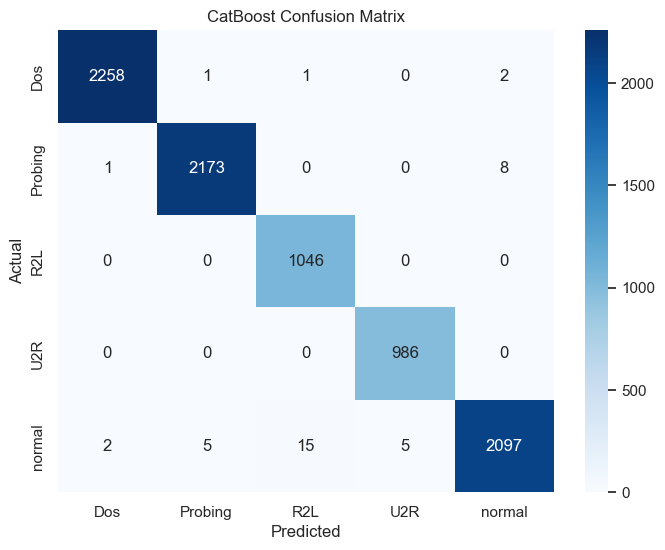

In [42]:
# Install if needed (usually pre-installed on Kaggle)
# !pip install catboost

from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# CatBoost model with class weights for rare classes
model = CatBoostClassifier(
    iterations=1000,
    depth=8,
    learning_rate=0.05,
    loss_function='MultiClass',
    auto_class_weights='Balanced',  # Great for your imbalanced rare classes
    verbose=100,
    random_seed=42
)

# Train
model.fit(X_train_scaled_df, y_train)

# Predict
y_pred_cat = model.predict(X_test_scaled_df)

# Evaluate
accuracy_cat = accuracy_score(y_test, y_pred_cat)
print(f"CatBoost Accuracy: {accuracy_cat * 100:.2f}%")

print("\nCatBoost Classification Report:")
print(classification_report(y_test, y_pred_cat,
                            target_names=['Dos', 'Probing', 'R2L', 'U2R', 'normal']))

# Confusion Matrix
cm_cat = confusion_matrix(y_test, y_pred_cat)
plt.figure(figsize=(8,6))
sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dos', 'Probing', 'R2L', 'U2R', 'normal'],
            yticklabels=['Dos', 'Probing', 'R2L', 'U2R', 'normal'])
plt.title('CatBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [43]:
# --- Save CatBoost Model ---
if not os.path.exists('saved_models'):
    os.makedirs('saved_models')

model.save_model('saved_models/catboost_model.cbm')

print("CatBoost model saved successfully!")
print("   - File: saved_models/catboost_model.cbm")

CatBoost model saved successfully!
   - File: saved_models/catboost_model.cbm


Epoch 50/256 completed
Epoch 100/256 completed
Epoch 150/256 completed
Epoch 200/256 completed
Epoch 250/256 completed
RealMLP Accuracy: 99.29%

RealMLP Classification Report:
              precision    recall  f1-score   support

         Dos       1.00      1.00      1.00      2262
     Probing       1.00      1.00      1.00      2182
         R2L       0.98      1.00      0.99      1046
         U2R       0.99      1.00      0.99       986
      normal       0.99      0.98      0.99      2124

    accuracy                           0.99      8600
   macro avg       0.99      0.99      0.99      8600
weighted avg       0.99      0.99      0.99      8600



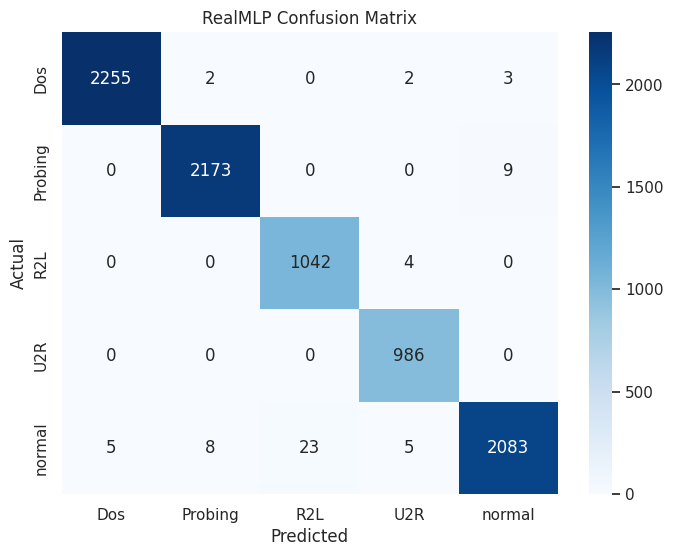

In [44]:
# --- RealMLP: Enhanced MLP with strong tuned defaults (NeurIPS 2024) ---
# Standalone implementation (no extra install needed - pure PyTorch)

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Convert data to torch tensors
X_train_t = torch.FloatTensor(X_train_scaled_df.values)
y_train_t = torch.LongTensor(y_train.values)
X_test_t = torch.FloatTensor(X_test_scaled_df.values)
y_test_t = torch.LongTensor(y_test.values)

n_features = X_train_t.shape[1]
n_classes = 5

# RealMLP Architecture (from the standalone implementation)
class RealMLP(nn.Module):
    def __init__(self, n_features, n_classes, dropout=0.5, hidden_size=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_size, hidden_size // 2),
            nn.BatchNorm1d(hidden_size // 2),
            nn.GELU(),
            
            nn.Linear(hidden_size // 2, n_classes)
        )
    
    def forward(self, x):
        return self.net(x)

# Initialize model
realmlp_model = RealMLP(n_features=n_features, n_classes=n_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(realmlp_model.parameters(), lr=0.001, weight_decay=0.01)

# Training loop (256 epochs as recommended)
realmlp_model.train()
batch_size = 256
n_epochs = 256

for epoch in range(n_epochs):
    permutation = torch.randperm(X_train_t.size(0))
    for i in range(0, X_train_t.size(0), batch_size):
        optimizer.zero_grad()
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = X_train_t[indices], y_train_t[indices]
        outputs = realmlp_model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
    
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} completed")

# Evaluation
realmlp_model.eval()
with torch.no_grad():
    outputs_test = realmlp_model(X_test_t)
    y_pred_realmlp = torch.argmax(outputs_test, dim=1).numpy()

accuracy_realmlp = accuracy_score(y_test, y_pred_realmlp)
print(f"RealMLP Accuracy: {accuracy_realmlp * 100:.2f}%")

print("\nRealMLP Classification Report:")
print(classification_report(y_test, y_pred_realmlp,
                            target_names=['Dos', 'Probing', 'R2L', 'U2R', 'normal']))

# Confusion Matrix
cm_realmlp = confusion_matrix(y_test, y_pred_realmlp)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_realmlp, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dos', 'Probing', 'R2L', 'U2R', 'normal'],
            yticklabels=['Dos', 'Probing', 'R2L', 'U2R', 'normal'])
plt.title('RealMLP Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [45]:
# --- Save RealMLP Model ---
import os

# Create a folder to store models (optional but clean)
if not os.path.exists('saved_models'):
    os.makedirs('saved_models')

# Save the full model (recommended for PyTorch)
torch.save(realmlp_model, 'saved_models/realmlp_full_model.pth')

# OR save only the state dict (smaller file, more flexible)
torch.save(realmlp_model.state_dict(), 'saved_models/realmlp_state_dict.pth')

print("RealMLP model saved successfully!")
print("   - Full model: saved_models/realmlp_full_model.pth")
print("   - State dict: saved_models/realmlp_state_dict.pth")

RealMLP model saved successfully!
   - Full model: saved_models/realmlp_full_model.pth
   - State dict: saved_models/realmlp_state_dict.pth


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:01:21] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Xgboost Accuracy: 99.69%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2262
           1       1.00      1.00      1.00      2182
           2       0.99      1.00      0.99      1046
           3       1.00      1.00      1.00       986
           4       1.00      0.99      0.99      2124

    accuracy                           1.00      8600
   macro avg       1.00      1.00      1.00      8600
weighted avg       1.00      1.00      1.00      8600



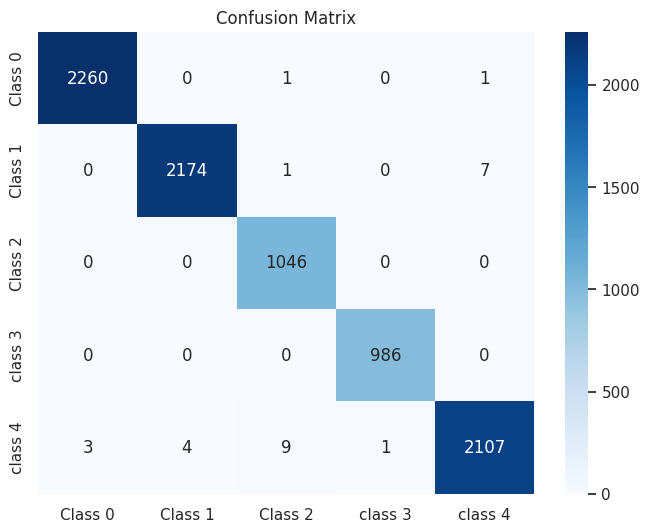

In [46]:
# Create an XGBoost model
xgb_model = XGBClassifier(
    objective='multi:softmax',  # Multi-class classification
    num_class=5,  # Number of classes in your dataset (0 to 4)
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# Train the model with the training data
xgb_model.fit(X_train_scaled_df, y_train)

# Make predictions on the test set
y_pred = xgb_model.predict(X_test_scaled_df)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Xgboost Accuracy: {accuracy * 100:.2f}%")

# Print classification report for detailed metrics (precision, recall, f1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))  # Adjust the figure size as needed
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Class 0", "Class 1", "Class 2", "class 3", "class 4"], yticklabels=["Class 0", "Class 1", "Class 2", "class 3", "class 4"])


plt.title('Confusion Matrix')

# Show the plot
plt.show()
